In [1]:
import os
import sys

REPO_URL = "https://github.com/gCorona45/Corona_Sechi.git"
REPO_DIR = "/content/Corona_Sechi"

# Detectar si estamos en Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    # Clonar el repositorio si no está presente
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
        print("Repositorio clonado correctamente.")
    
    # Navegar a la carpeta del experimento
    os.chdir(os.path.join(REPO_DIR, "k_brazos"))
    
    # Añadir src al path
    sys.path.append(os.path.join(REPO_DIR, "k_brazos", "src"))
    
    # Instalar dependencias
    !pip install -q tqdm matplotlib seaborn
    print(f"Directorio de trabajo: {os.getcwd()}")
else:
    # Ejecución local: src ya está accesible
    sys.path.append(os.path.join(os.getcwd(), 'src'))

In [4]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
src_path = os.path.join(parent_dir, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

# --- IMPORTACIONES ---
from utils import set_global_seed
from armnormal import ArmNormal
from algorithms import UCB1, UCB1Tuned, UCB2,UCBV

# Configuración de la semilla global
SEED = 2024
set_global_seed(SEED)

Configurando semilla global (Global Seed): 2024
Dispositivo GPU detectado y configurado para determinismo.


In [5]:
print("Iniciando Estudio Comparativo de la Familia UCB...")

# --- PARÁMETROS DEL EXPERIMENTO ---
K_ARMS = 10
N_STEPS = 5000 
N_RUNS = 500

# 1. Generación del Entorno (Distribución Normal)
# Usamos el método generador estricto proporcionado en la arquitectura base
entorno_brazos = ArmNormal.generate_arms(k=K_ARMS, mu_min=1.0, mu_max=30.0)

# Extraer medias teóricas para cálculo de regret
arm_means = [brazo.get_expected_value() for brazo in entorno_brazos]
arm_sigmas = [brazo.sigma for brazo in entorno_brazos]
optimal_expected_value = max(arm_means)
optimal_arm_idx = np.argmax(arm_means)

print(f"Brazos generados automáticamente (Medias): {arm_means}")
print(f"Brazo Óptimo: Índice {optimal_arm_idx} (Media teórica = {optimal_expected_value})")
print(f" - Desviaciones (σ): {arm_sigmas}")
# 2. Instanciación de Algoritmos
algoritmos = [
    UCB1(k=K_ARMS),
    UCB1Tuned(k=K_ARMS),
    UCB2(k=K_ARMS, alpha=0.5),

    UCB2(k=K_ARMS, alpha=0.1),  # Más agresivo
    UCB2(k=K_ARMS, alpha=0.9),  # Más conservador
    
]

n_algos = len(algoritmos)
avg_rewards = np.zeros((n_algos, N_STEPS))
avg_optimal_selections = np.zeros((n_algos, N_STEPS))
avg_regret = np.zeros((n_algos, N_STEPS))

# 3. Bucle de Simulación Monte Carlo
for run in tqdm(range(N_RUNS), desc="Simulando Runs"):
    
    # Reiniciar estado
    for algo in algoritmos:
        algo.reset()
        
    run_rewards = np.zeros((n_algos, N_STEPS))
    run_opt_sel = np.zeros((n_algos, N_STEPS))
    run_regret = np.zeros((n_algos, N_STEPS))
    
    for t in range(N_STEPS):
        for i, algo in enumerate(algoritmos):
            # Selección
            chosen_arm = algo.select_arm()
            
            # Recompensa desde el objeto
            reward = entorno_brazos[chosen_arm].pull()
            
            # Actualización
            algo.update(chosen_arm, reward)
            
            # Registro
            run_rewards[i, t] = reward
            run_opt_sel[i, t] = 1 if chosen_arm == optimal_arm_idx else 0
            
            inst_regret = optimal_expected_value - arm_means[chosen_arm]
            run_regret[i, t] = inst_regret if t == 0 else run_regret[i, t-1] + inst_regret
                
    # Acumulación
    avg_rewards += run_rewards
    avg_optimal_selections += run_opt_sel
    avg_regret += run_regret

# Promedios finales
avg_rewards /= N_RUNS
avg_optimal_selections /= N_RUNS
avg_regret /= N_RUNS

Iniciando Estudio Comparativo de la Familia UCB...
Brazos generados automáticamente (Medias): [2.2704, 4.0758, 6.4564, 6.9455, 14.7415, 14.0006, 18.0524, 20.7026, 21.2742, 22.09]
Brazo Óptimo: Índice 9 (Media teórica = 22.09)
 - Desviaciones (σ): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


Simulando Runs: 100%|██████████| 500/500 [03:52<00:00,  2.15it/s]


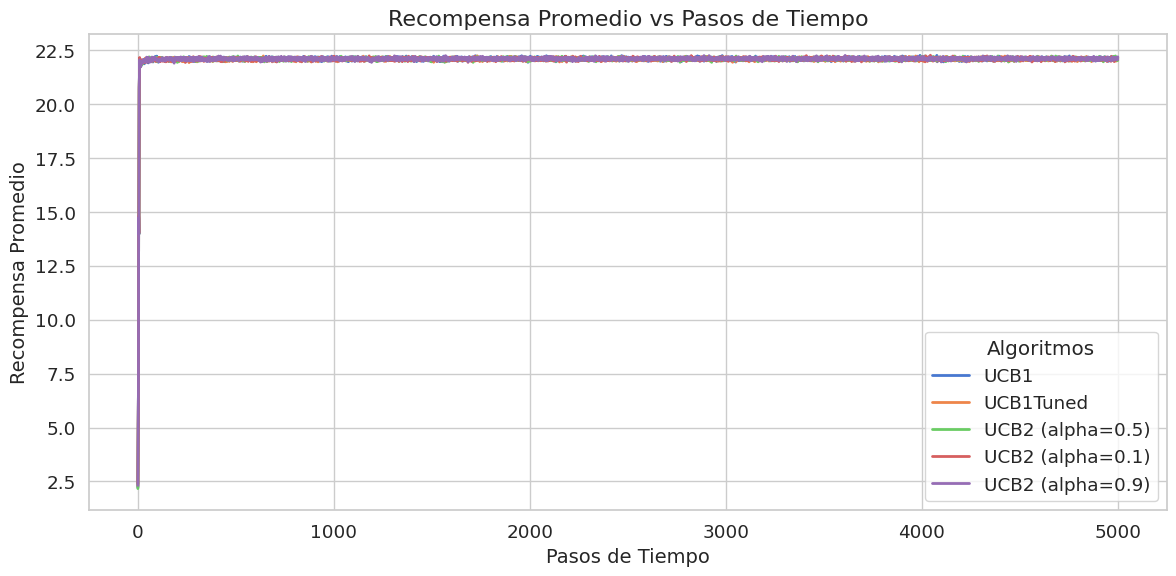

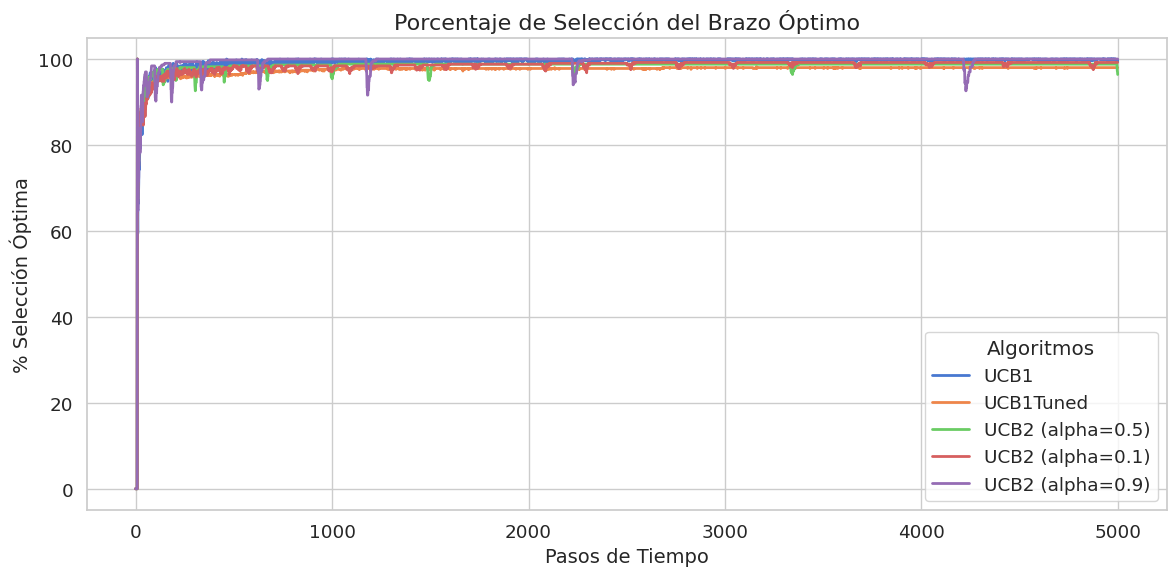

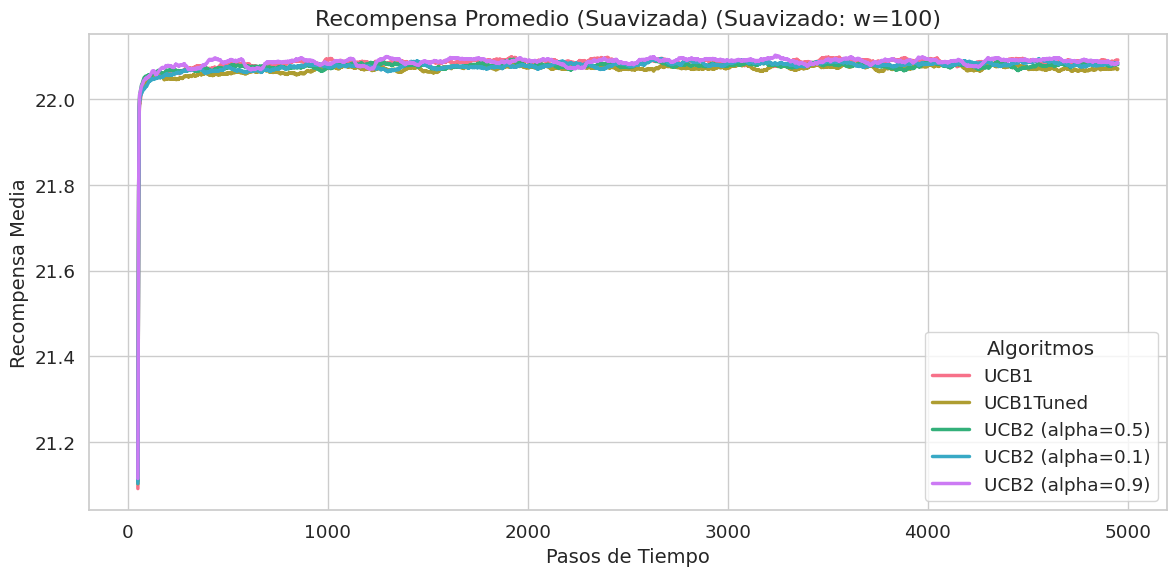

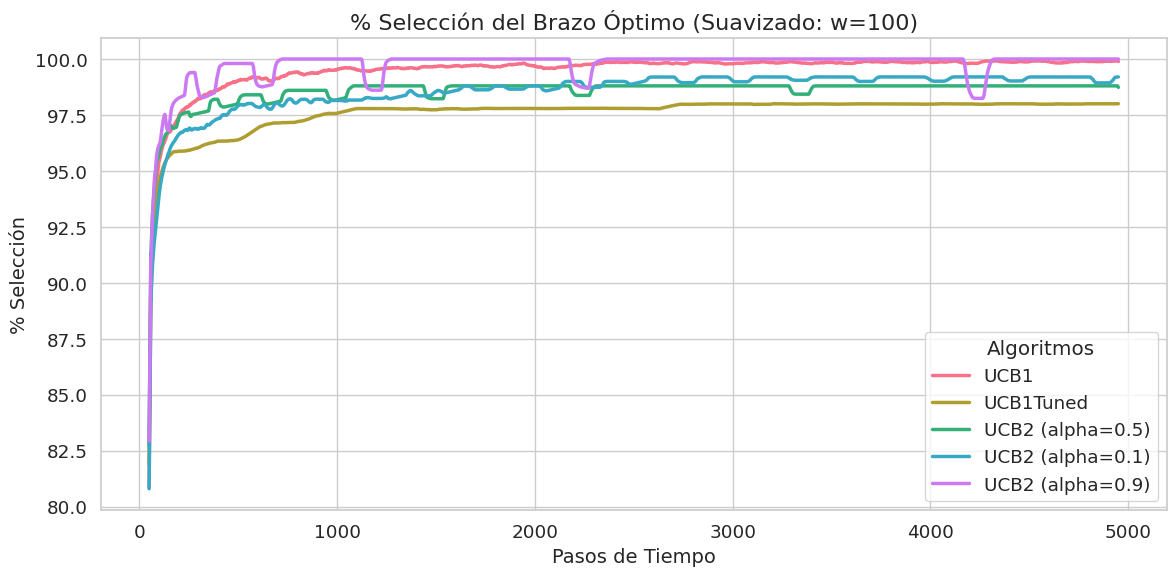

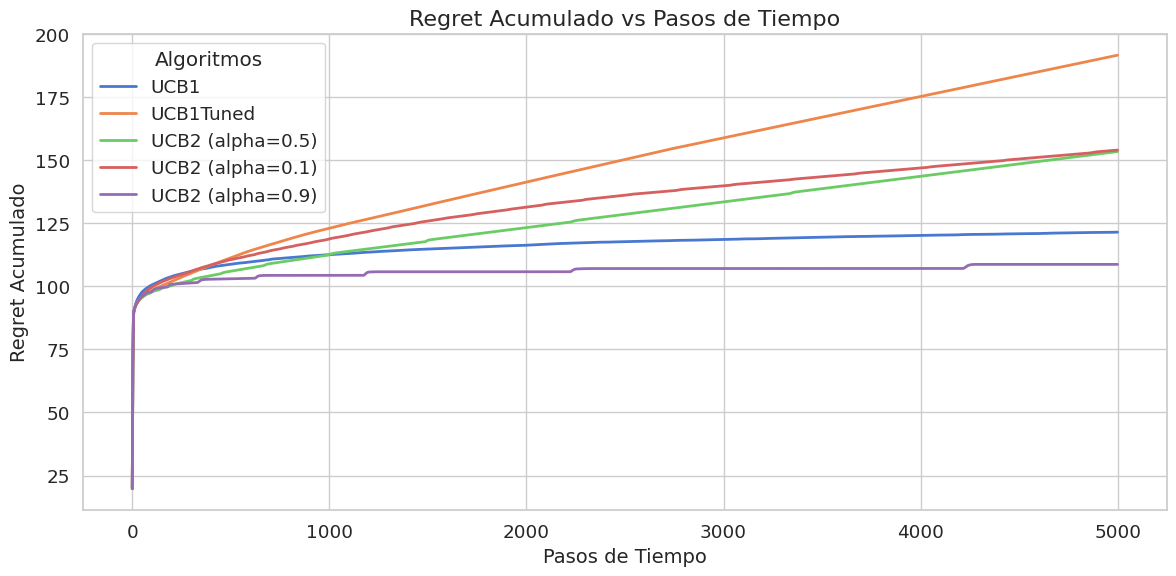

In [6]:
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_smoothed_curves, plot_arm_statistics

plot_average_rewards(N_STEPS, avg_rewards, algoritmos)
plot_optimal_selections(N_STEPS, avg_optimal_selections, algoritmos)
# -------------------------------------------------------
# 1. Gráfica de Recompensa Promedio (MEJORADA - Suavizada)
# -------------------------------------------------------
# Usamos 'plot_smoothed_curves' para reducir el ruido visual típico de Bernoulli.
# Añadimos la línea de referencia del óptimo teórico.

plot_smoothed_curves(steps=N_STEPS, 
                     data=avg_rewards, 
                     algorithms=algoritmos, 
                     title="Recompensa Promedio (Suavizada)", 
                     ylabel="Recompensa Media", 
                     window_size=100, 
                     )

# -------------------------------------------------------
# 2. Porcentaje de Selección del Brazo Óptimo (MEJORADA)
# -------------------------------------------------------
# Multiplicamos por 100 para visualizarlo como porcentaje.
plot_smoothed_curves(steps=N_STEPS, 
                     data=avg_optimal_selections * 100, 
                     algorithms=algoritmos, 
                     title="% Selección del Brazo Óptimo", 
                     ylabel="% Selección", 
                     window_size=100, 
                     )

# -------------------------------------------------------
# 3. Regret Acumulado
# -------------------------------------------------------
# El Regret ya es una métrica acumulativa, por lo que suele ser suave per se.
# Mantenemos la función estándar 'plot_regret'.
plot_regret(N_STEPS, avg_regret, algoritmos)


## 3. Análisis y Discusión de Resultados: Estudio Comparativo de la Familia UCB

El presente experimento evalúa el rendimiento interno de la familia de algoritmos Upper Confidence Bound (UCB1, UCB1-Tuned y UCB2 con tres calibraciones de $\alpha$) sometidos a un entorno estocástico Normal con varianza homogénea baja ($\sigma=1.0$ para todos los brazos). Los resultados empíricos revelan divergencias significativas en el comportamiento exploratorio derivadas de sus respectivas formulaciones matemáticas.

### A. Análisis de Convergencia (% Selección Óptima)
La gráfica de selección óptima ilustra la velocidad a la que cada algoritmo aísla el mejor brazo:

1. **Dominio de UCB2 ($\alpha=0.9$):** Esta variante alcanza un porcentaje de selección óptima cercano al $100\%$ antes que cualquier otra, estabilizándose de forma casi inmediata tras las primeras centenas de iteraciones. Su mecanismo de épocas de crecimiento exponencial, calibrado con un $\alpha$ alto, le permite "bloquear" el brazo óptimo una vez identificado, extendiendo al máximo las fases de explotación ininterrumpida.
2. **UCB1 y UCB2 ($\alpha=0.1$):** Ambos alcanzan niveles de convergencia elevados ($\approx 99\%$), aunque con una trayectoria más gradual que UCB2($\alpha=0.9$). UCB1 recalcula sus límites de confianza en cada paso temporal, lo que lo obliga a revisitar periódicamente brazos ya descartados. UCB2($\alpha=0.1$), con épocas más cortas, presenta un comportamiento similar al de UCB1.
3. **UCB1-Tuned:** Presenta la convergencia más lenta de la familia ($\approx 98\%$), quedando consistentemente por debajo de UCB1 y UCB2. Esto resulta revelador: diseñado para aprovechar la varianza empírica de cada brazo, ante la escasez de ruido real ($\sigma=1.0$ homogéneo) su estimación inicial introduce un margen de incertidumbre ficticio que lo fuerza a sobre-explorar innecesariamente.
4. **UCB2 ($\alpha=0.5$):** Exhibe un comportamiento intermedio, con una convergencia comparable a UCB1 pero sin lograr alcanzar la eficiencia de UCB2($\alpha=0.9$).

### B. Análisis del Regret Acumulado (Coste de Aprendizaje)
La gráfica de Regret Acumulado confirma y cuantifica el coste de las políticas de exploración:

* **UCB2 ($\alpha=0.9$) como límite de rendimiento:** Con un regret final de $\approx 110$, marca el rendimiento óptimo absoluto del experimento. Sus épocas exponenciales largas suprimen la tasa constante de exploración, minimizando el coste de aprendizaje una vez aislado el brazo óptimo.
* **UCB1:** Acumula un regret de $\approx 120$, el segundo mejor del estudio. Su diseño iterativo — recalcular los límites de confianza en cada paso — lo obliga a revisitar brazos subóptimos con una frecuencia superior a la de UCB2($\alpha=0.9$), pero mantiene un perfil de crecimiento logarítmico sólido.
* **UCB1-Tuned y UCB2 ($\alpha=0.1$):** Ambos convergen a un regret de $\approx 155$, significativamente superior al de UCB1. En el caso de UCB1-Tuned, la sobreestimación de la incertidumbre ante varianza real baja se traduce directamente en exploraciones innecesarias. UCB2($\alpha=0.1$), con épocas demasiado cortas, se comporta de manera análoga a un UCB1 con mayor coste de actualización.
* **UCB2 ($\alpha=0.5$):** Presenta el peor rendimiento del estudio con un regret cercano a $\approx 195$, en crecimiento lineal sostenido. Este valor de $\alpha$ genera épocas de longitud intermedia que no son lo suficientemente largas para consolidar la explotación ni lo suficientemente cortas para garantizar una exploración eficiente, quedando atrapado en una zona subóptima del espacio de diseño.

### C. Conclusiones y Justificación Técnica
Este estudio demuestra empíricamente que, en entornos de bajo ruido con poca superposición entre distribuciones:

1. **UCB2 ($\alpha=0.9$)** es la arquitectura más eficiente para minimizar el regret asintótico. Al calibrar épocas de crecimiento exponencial suficientemente largas, el algoritmo logra aislar el óptimo de forma inmediata y bloquear su explotación, suprimiendo la exploración residual que penaliza a las demás variantes.
2. **UCB1** mantiene un rendimiento robusto y competitivo sin necesidad de calibración de hiperparámetros, consolidándose como la opción más segura cuando no se dispone de conocimiento previo sobre la topología del entorno.
3. **UCB1-Tuned** evidencia una fragilidad estructural en escenarios de varianza homogénea baja. Su incorporación de la varianza empírica, diseñada para mejorar la eficiencia en entornos heterogéneos, se convierte en una fuente de ruido artificial cuando la varianza real es uniformemente reducida.
4. La calibración de $\alpha$ en UCB2 es crítica: valores demasiado bajos ($\alpha=0.1$) anulan la ventaja del mecanismo de épocas, mientras que valores intermedios ($\alpha=0.5$) pueden generar el peor rendimiento de toda la familia.